# Practical Single-Block Replacement Baseline

## Research question

Can a fixed reduced-width SwiGLU approximate the MLP at zero-based SmolLM2 layer 11 better than input-independent controls while using substantially fewer parameters?

This notebook evaluates one deliberately chosen replacement, not an architecture search. Every condition uses the same held-out activation pairs and model-validation batches. Candidates are inserted one at a time, and model-level recovery is disabled.

## Compared conditions

| Condition | Role | Trainable replacement parameters |
| --- | --- | ---: |
| Original MLP | Uncompressed quality reference | Original block count |
| Zero | Complete-removal control | 0 |
| Mean | Calibration-output mean control | 0 |
| Narrow SwiGLU | Learned practical replacement with width r = d_model / 2 | 3 d_model r |

For the configured model, d_model = 2048 and r = 1024. The expected narrow-SwiGLU count is 6,291,456 parameters, or 12.5% of the original 50,331,648-parameter MLP.

The fixed width is a project decision for this baseline. Results cannot establish that this width or operator family is optimal.

In [1]:
from dataclasses import asdict
from pathlib import Path
import json
import sys

def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from mlp_replacement.capture import collect_module_io
from mlp_replacement.config import DataConfig, ModelConfig, OperatorConfig
from mlp_replacement.data import build_data_loaders
from mlp_replacement.evaluation.language_model import evaluate_language_model
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import get_mlp_block, load_model_and_tokenizer
from mlp_replacement.operators import (
    GatedMLPReplacement,
    MeanReplacement,
    ZeroReplacement,
    fit_operator,
)
from mlp_replacement.runlog import environment_record, json_value
from mlp_replacement.surgery import (
    count_parameters,
    count_state_elements,
    temporary_replacement,
)

sns.set_theme(style='whitegrid', context='notebook')

In [2]:
TARGET_LAYER = 11
SEED = 21
REPLACEMENT_WIDTH_RATIO = 0.5
OUTPUT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / f'baselines-layer-{TARGET_LAYER}.json'
)

model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)
data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=0,
    num_recovery_validation_batches=0,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)
training_config = OperatorConfig(
    kind='bottleneck_mlp',
    bottleneck_ratio=REPLACEMENT_WIDTH_RATIO,
    activation='silu',
    bias=False,
    epochs=20,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)
torch.manual_seed(SEED)

print({
    'target_layer': TARGET_LAYER,
    'replacement_width_ratio': REPLACEMENT_WIDTH_RATIO,
    'output': str(OUTPUT_PATH),
})

{'target_layer': 11, 'replacement_width_ratio': 0.5, 'output': '/home/sgulas/thesis/development/data/results/notebook-block-study/baselines-layer-11.json'}


## Shared data and block capture

Calibration pairs fit the learned replacement and define the mean control. A document-disjoint operator-validation split measures local approximation. WikiText-2 validation batches measure model loss and perplexity after temporary insertion.

In [3]:
model, tokenizer = load_model_and_tokenizer(model_config)
device = next(model.parameters()).device
loaders = build_data_loaders(tokenizer, data_config, include_recovery=False)
block = get_mlp_block(model, TARGET_LAYER)

capture_kwargs = {
    'device': device,
    'storage_device': 'cpu',
    'storage_dtype': torch.float32,
}
training_pairs = collect_module_io(
    model,
    block.path,
    loaders.calibration,
    data_config.num_calibration_batches,
    **capture_kwargs,
)
validation_pairs = collect_module_io(
    model,
    block.path,
    loaders.operator_validation,
    data_config.num_operator_validation_batches,
    **capture_kwargs,
)

hidden_size = training_pairs.hidden_size
replacement_width = hidden_size // 2
original_parameters = count_parameters(block.module)
original_state_elements = count_state_elements(block.module)

narrow_swiglu = GatedMLPReplacement(
    hidden_size,
    replacement_width,
    bias=False,
)
replacement_parameters = count_parameters(narrow_swiglu)
replacement_state_elements = count_state_elements(narrow_swiglu)

capture_df = pd.DataFrame([
    {
        'split': 'calibration',
        'tokens': training_pairs.inputs.shape[0],
        'input_dimension': training_pairs.inputs.shape[1],
        'target_dimension': training_pairs.targets.shape[1],
    },
    {
        'split': 'operator_validation',
        'tokens': validation_pairs.inputs.shape[0],
        'input_dimension': validation_pairs.inputs.shape[1],
        'target_dimension': validation_pairs.targets.shape[1],
    },
])
capture_df

/home/sgulas/miniconda3/envs/mlp-replacement/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 218/218 [00:00<00:00, 6229.79it/s]
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (268279 > 8192). Running this sequence through the model will result in indexing errors


,split,tokens,input_dimension,target_dimension
0,calibration,12288,2048,2048
1,operator_validation,6144,2048,2048


In [4]:
footprint_df = pd.DataFrame([
    {
        'operator': 'original_mlp',
        'intermediate_width': int(block.module.up_proj.out_features),
        'parameters': original_parameters,
        'state_elements': original_state_elements,
        'relative_block_parameters': 1.0,
        'parameter_reduction_percent': 0.0,
    },
    {
        'operator': 'narrow_swiglu',
        'intermediate_width': replacement_width,
        'parameters': replacement_parameters,
        'state_elements': replacement_state_elements,
        'relative_block_parameters': replacement_parameters / original_parameters,
        'parameter_reduction_percent': 100 * (
            1 - replacement_parameters / original_parameters
        ),
    },
])

expected_replacement_parameters = 3 * hidden_size * replacement_width
if replacement_parameters != expected_replacement_parameters:
    raise RuntimeError(
        'Unexpected narrow-SwiGLU parameter count: '
        f'{replacement_parameters} != {expected_replacement_parameters}'
    )
footprint_df

,operator,intermediate_width,parameters,state_elements,relative_block_parameters,parameter_reduction_percent
0,original_mlp,8192,50331648,50331648,1.000,0.0
1,narrow_swiglu,1024,6291456,6291456,0.125,87.5


## Fit and evaluate the four conditions

The zero and mean controls require no optimization. The narrow SwiGLU is trained only against the frozen teacher block output using activation MSE. Each replacement is then evaluated locally and inserted temporarily for the same language-model evaluation.

In [5]:
baseline_lm = evaluate_language_model(
    model,
    loaders.model_validation,
    device,
    data_config.num_model_validation_batches,
)
results = [{
    'name': 'original_mlp',
    'family': 'teacher',
    'parameters': original_parameters,
    'state_elements': original_state_elements,
    'relative_block_parameters': 1.0,
    'removed_parameters': 0,
    'local_mse': 0.0,
    'local_relative_mse': 0.0,
    'local_r2': 1.0,
    'local_cosine': 1.0,
    'local_norm_ratio': 1.0,
    'median_token_relative_error': 0.0,
    'p95_token_relative_error': 0.0,
    'loss': baseline_lm.loss,
    'perplexity': baseline_lm.perplexity,
    'delta_loss': 0.0,
    'delta_perplexity': 0.0,
    'recovery': False,
}]
training_histories = {}

def append_candidate(name, family, module, history=()):
    module = module.to(device)
    local = evaluate_operator(
        module,
        validation_pairs,
        device,
        training_config.batch_size,
    )
    with temporary_replacement(model, TARGET_LAYER, module) as record:
        integrated = evaluate_language_model(
            model,
            loaders.model_validation,
            device,
            data_config.num_model_validation_batches,
        )

    parameters = count_parameters(module)
    state_elements = count_state_elements(module)
    results.append({
        'name': name,
        'family': family,
        'parameters': parameters,
        'state_elements': state_elements,
        'relative_block_parameters': parameters / original_parameters,
        'removed_parameters': record.original_parameters - parameters,
        'local_mse': local.mse,
        'local_relative_mse': local.relative_mse,
        'local_r2': local.r2,
        'local_cosine': local.cosine_similarity,
        'local_norm_ratio': local.norm_ratio,
        'median_token_relative_error': local.median_token_relative_error,
        'p95_token_relative_error': local.p95_token_relative_error,
        'loss': integrated.loss,
        'perplexity': integrated.perplexity,
        'delta_loss': integrated.loss - baseline_lm.loss,
        'delta_perplexity': integrated.perplexity - baseline_lm.perplexity,
        'recovery': False,
    })
    training_histories[name] = [asdict(epoch) for epoch in history]

append_candidate(
    'zero',
    'constant_control',
    ZeroReplacement(),
)
append_candidate(
    'mean',
    'constant_control',
    MeanReplacement(training_pairs.targets.mean(dim=0)),
)

torch.manual_seed(SEED)
fit = fit_operator(
    narrow_swiglu,
    training_pairs,
    validation_pairs,
    training_config,
    device,
)
append_candidate(
    'narrow_swiglu',
    'gated_mlp',
    fit.module,
    fit.history,
)

results_df = pd.DataFrame(results)
if len(results_df) != 4:
    raise RuntimeError(f'Expected exactly four result rows, found {len(results_df)}')

## Learned-operator fit

The curves below diagnose optimization of the single learned replacement. They do not compare architectures.

,epoch,train_mse,validation_mse,learning_rate
0,1,1.601604,1.554924,0.001
1,2,1.583115,1.524481,0.001
2,3,1.548928,1.502012,0.001
3,4,1.518044,1.480281,0.001
4,5,1.482420,1.449271,0.001
5,6,1.439397,1.420505,0.001
6,7,1.394170,1.391438,0.001
7,8,1.348414,1.363407,0.001
8,9,1.305290,1.338719,0.001
9,10,1.263634,1.314655,0.001


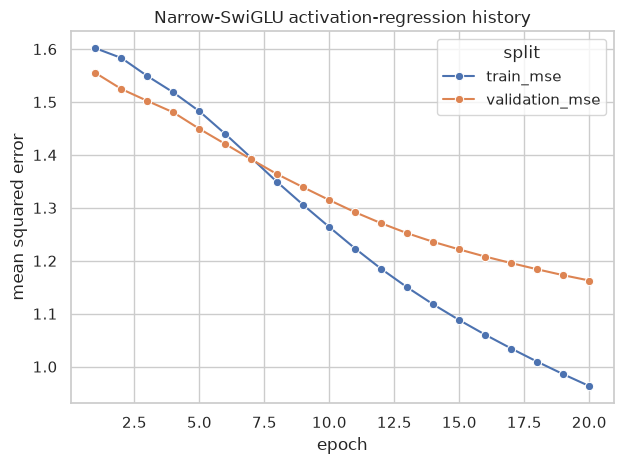

In [6]:
history_df = pd.DataFrame(training_histories['narrow_swiglu'])
history_long = history_df.melt(
    id_vars='epoch',
    value_vars=['train_mse', 'validation_mse'],
    var_name='split',
    value_name='mse',
)

ax = sns.lineplot(
    data=history_long,
    x='epoch',
    y='mse',
    hue='split',
    marker='o',
)
ax.set(
    title='Narrow-SwiGLU activation-regression history',
    ylabel='mean squared error',
)
plt.tight_layout()

history_df

## Footprint-quality report

The table retains the local approximation and integrated model metrics needed to interpret the replacement. The figure shows footprint and quality together without implying a searched Pareto frontier.

In [7]:
report_columns = [
    'name',
    'parameters',
    'state_elements',
    'relative_block_parameters',
    'local_relative_mse',
    'local_cosine',
    'loss',
    'perplexity',
    'delta_loss',
    'delta_perplexity',
]
results_df[report_columns]

,name,parameters,state_elements,relative_block_parameters,local_relative_mse,local_cosine,loss,perplexity,delta_loss,delta_perplexity
0,original_mlp,50331648,50331648,1.000,0.000000,1.000000,2.669973,14.439586,0.000000,0.000000
1,zero,0,0,0.000,1.000000,0.000000,2.737755,15.452254,0.067781,1.012669
2,mean,0,2048,0.000,0.968830,0.169191,2.736986,15.440385,0.067013,1.000799
3,narrow_swiglu,6291456,6291456,0.125,0.745321,0.498382,2.724601,15.250334,0.054628,0.810748


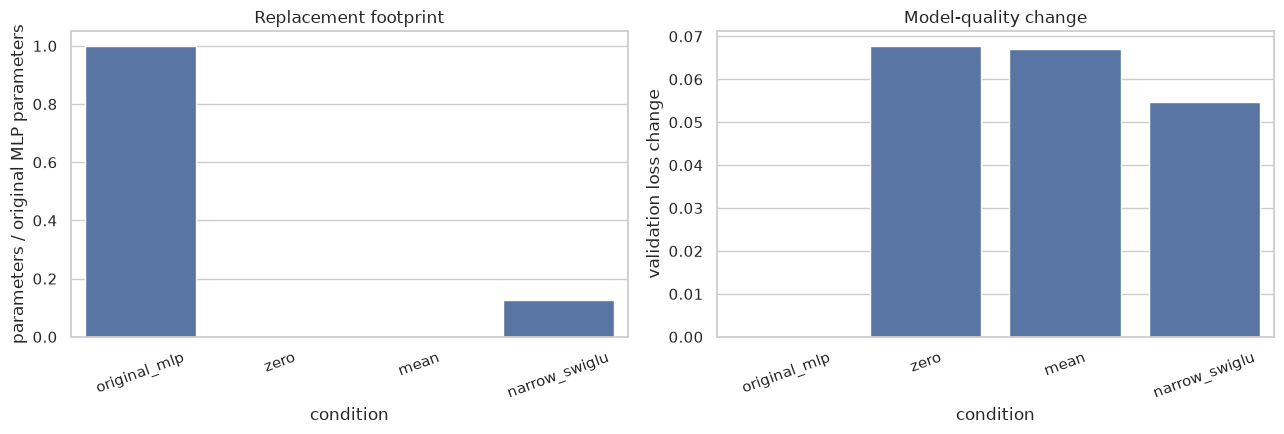

In [8]:
condition_order = ['original_mlp', 'zero', 'mean', 'narrow_swiglu']
plot_df = results_df.set_index('name').loc[condition_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(
    data=plot_df,
    x='name',
    y='relative_block_parameters',
    order=condition_order,
    ax=axes[0],
)
sns.barplot(
    data=plot_df,
    x='name',
    y='delta_loss',
    order=condition_order,
    ax=axes[1],
)
axes[0].set(
    title='Replacement footprint',
    xlabel='condition',
    ylabel='parameters / original MLP parameters',
)
axes[1].set(
    title='Model-quality change',
    xlabel='condition',
    ylabel='validation loss change',
)
for axis in axes:
    axis.tick_params(axis='x', rotation=20)
plt.tight_layout()

In [9]:
artifact = {
    'schema_version': 2,
    'status': 'exploratory-unverified',
    'model': {
        'id': model_config.model_id,
        'resolved_revision': getattr(model.config, '_commit_hash', None),
        'target_layer': TARGET_LAYER,
        'mlp_path': block.path,
        'requested_config': asdict(model_config),
    },
    'data': {
        'sequence_length': data_config.sequence_length,
        'calibration_batches': data_config.num_calibration_batches,
        'operator_validation_batches': data_config.num_operator_validation_batches,
        'model_validation_batches': data_config.num_model_validation_batches,
        'seed': SEED,
        'requested_config': asdict(data_config),
    },
    'environment': environment_record(),
    'recovery': False,
    'replacement': {
        'name': 'narrow_swiglu',
        'family': 'gated_mlp',
        'definition': 'down(silu(gate(x)) * up(x))',
        'hidden_size': hidden_size,
        'bottleneck_size': replacement_width,
        'bottleneck_ratio': replacement_width / hidden_size,
        'bias': False,
        'parameters': replacement_parameters,
        'state_elements': replacement_state_elements,
        'relative_block_parameters': (
            replacement_parameters / original_parameters
        ),
    },
    'controls': ['original_mlp', 'zero', 'mean'],
    'operator_training': asdict(training_config),
    'baseline_language_model': asdict(baseline_lm),
    'results': results_df.to_dict(orient='records'),
    'training_histories': training_histories,
}
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(
    json.dumps(json_value(artifact), indent=2, allow_nan=False),
    encoding='utf-8',
)
print(f'Saved baseline summary to {OUTPUT_PATH}')

Saved baseline summary to /home/sgulas/thesis/development/data/results/notebook-block-study/baselines-layer-11.json


## Results and interpretation

**Pending remote execution.** This rewritten notebook contains no preserved numerical output. After a clean remote run, report:

1. whether the narrow SwiGLU improves held-out local error over both trivial controls;
2. its model-loss and perplexity changes relative to the original MLP;
3. whether the observed degradation is acceptable for its 87.5% block-parameter reduction; and
4. whether the result justifies a later width or operator-family ablation.

### Interpretation boundary

This is one model, one layer, one calibration distribution, and one seed without recovery. The selected r = d_model / 2 width is a practical reference point, not an estimate of an optimal or smallest viable operator.